# Proyecto Mini #1: Análisis de la Felicidad Mundial

**Contexto:** Cada año, la ONU publica el "World Happiness Report", un estudio que mide el estado de la felicidad global. El informe clasifica a los países según su puntuación de felicidad y analiza los factores que contribuyen a ella.

**Objetivo:** Vuestro objetivo como analistas de datos es explorar el dataset del informe para entender qué factores están más correlacionados con la felicidad y cómo se distribuye esta en el mundo.

**Preguntas a Responder:**
1.  **Ranking de Felicidad:** ¿Cuáles son los 10 países más felices y los 10 menos felices del mundo según su puntuación (`Ladder score`)?
2.  **Riqueza y Felicidad:** ¿Existe una relación visible entre la riqueza de un país (`Logged GDP per capita`) y su puntuación de felicidad? Crea una visualización que lo demuestre.
3.  **Calidad de Vida:** ¿Qué relación hay entre la esperanza de vida (`Healthy life expectancy`) y la felicidad?
4.  **Análisis Regional:** ¿Qué región del mundo tiene, en promedio, la puntuación de felicidad más alta? Crea un gráfico de barras para comparar las regiones.

**Fuente de Datos:** [World Happiness Report 2021 en Kaggle](https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2021) (fichero `world-happiness-report-2021.csv`).

--- 1. Ranking de Felicidad ---
Los 10 países más felices:
    Country name  Ladder score
148  Afghanistan         2.523
147     Zimbabwe         3.145
146       Rwanda         3.415
145     Botswana         3.467
144      Lesotho         3.512
143       Malawi         3.600
142        Haiti         3.615
141     Tanzania         3.623
140        Yemen         3.658
139      Burundi         3.775

Los 10 países menos felices:
  Country name  Ladder score
0      Finland         7.842
1      Denmark         7.620
2  Switzerland         7.571
3      Iceland         7.554
4  Netherlands         7.464
5       Norway         7.392
6       Sweden         7.363
7   Luxembourg         7.324
8  New Zealand         7.277
9      Austria         7.268

--- 2. Gráfico: Riqueza vs. Felicidad ---


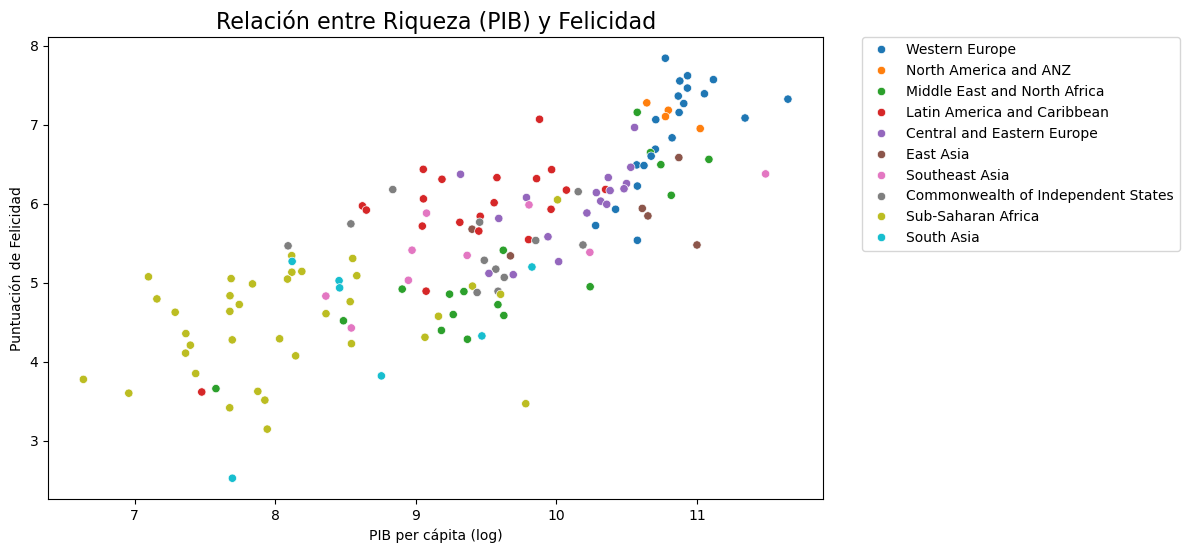

Observación: Se aprecia una clara correlación positiva. A mayor PIB per cápita, mayor suele ser la puntuación de felicidad.

--- 3. Gráfico: Esperanza de Vida vs. Felicidad ---


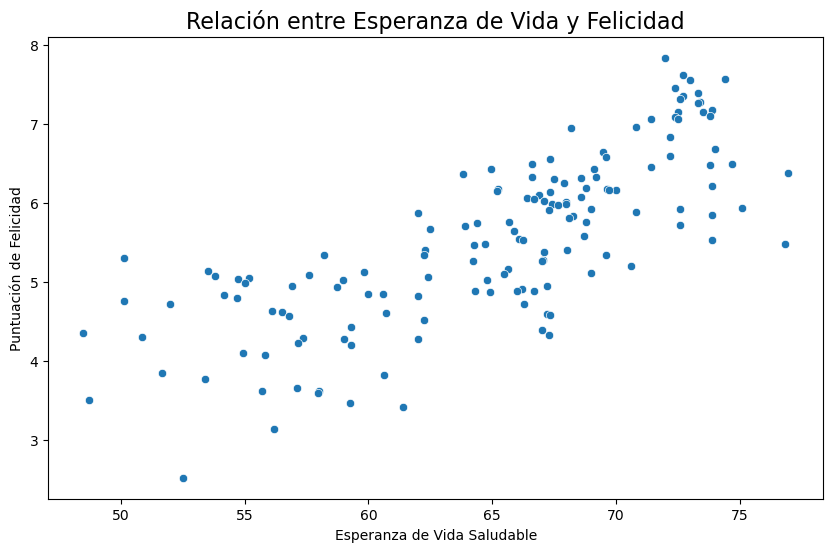

Observación: Al igual que con el PIB, existe una fuerte correlación positiva entre la esperanza de vida y la felicidad.

--- 4. Gráfico: Felicidad Media por Región ---


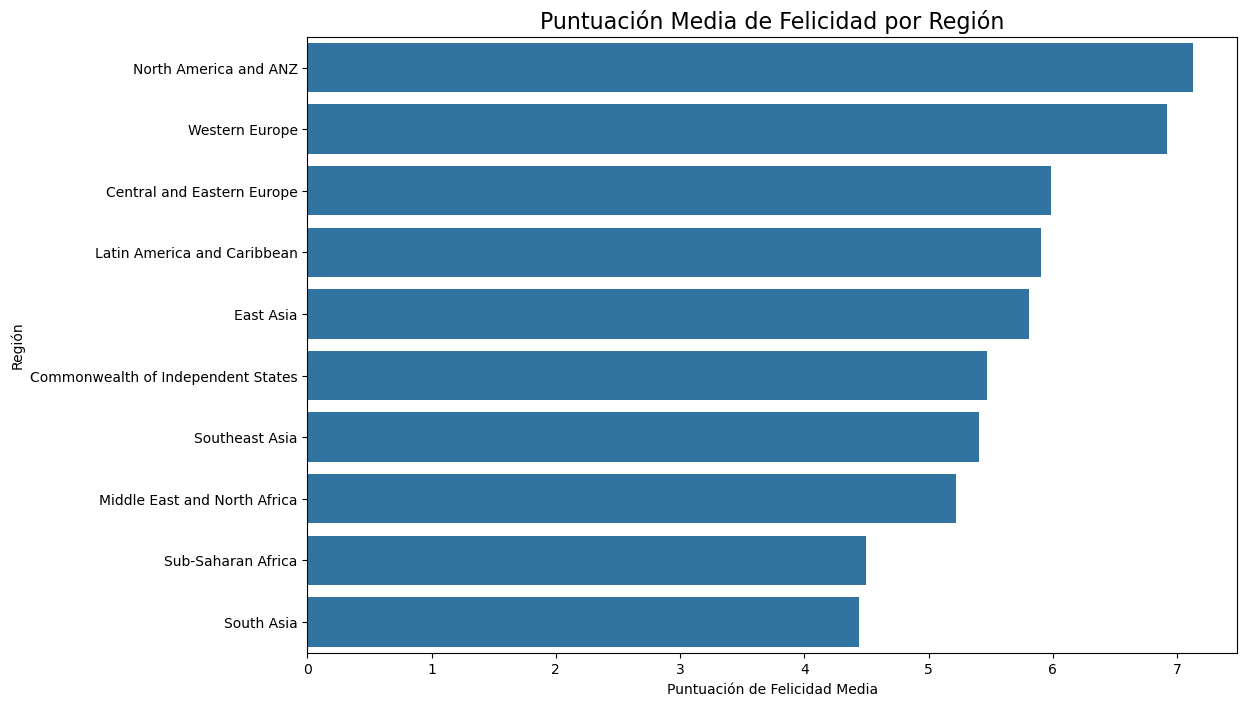

La región más feliz en promedio es: North America and ANZ


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar los datos
df = pd.read_csv('world-happiness-report-2021.csv')

# --- Pregunta 1: Ranking de Felicidad ---
print("--- 1. Ranking de Felicidad ---")
top_10_felices = df.nsmallest(10, 'Ladder score')
bottom_10_felices = df.nlargest(10, 'Ladder score')

print("Los 10 países más felices:")
print(top_10_felices[['Country name', 'Ladder score']])
print("\nLos 10 países menos felices:")
print(bottom_10_felices[['Country name', 'Ladder score']])


# --- Pregunta 2: Riqueza y Felicidad ---
print("\n--- 2. Gráfico: Riqueza vs. Felicidad ---")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Logged GDP per capita', y='Ladder score', hue='Regional indicator')
plt.title('Relación entre Riqueza (PIB) y Felicidad', fontsize=16)
plt.xlabel('PIB per cápita (log)')
plt.ylabel('Puntuación de Felicidad')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()
print("Observación: Se aprecia una clara correlación positiva. A mayor PIB per cápita, mayor suele ser la puntuación de felicidad.")


# --- Pregunta 3: Calidad de Vida y Felicidad ---
print("\n--- 3. Gráfico: Esperanza de Vida vs. Felicidad ---")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Healthy life expectancy', y='Ladder score')
plt.title('Relación entre Esperanza de Vida y Felicidad', fontsize=16)
plt.xlabel('Esperanza de Vida Saludable')
plt.ylabel('Puntuación de Felicidad')
plt.show()
print("Observación: Al igual que con el PIB, existe una fuerte correlación positiva entre la esperanza de vida y la felicidad.")


# --- Pregunta 4: Análisis Regional ---
print("\n--- 4. Gráfico: Felicidad Media por Región ---")
felicidad_regional = df.groupby('Regional indicator')['Ladder score'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=felicidad_regional.values, y=felicidad_regional.index)
plt.title('Puntuación Media de Felicidad por Región', fontsize=16)
plt.xlabel('Puntuación de Felicidad Media')
plt.ylabel('Región')
plt.show()
print(f"La región más feliz en promedio es: {felicidad_regional.index[0]}")

# Proyecto Mini #1: Análisis de Ventas de Videojuegos

**Contexto:** Una empresa de análisis de mercado quiere publicar un informe sobre las tendencias históricas en la industria de los videojuegos. Necesitan un análisis de datos para entender qué géneros, plataformas y editoras (publishers) han dominado el mercado.

**Objetivo:** Explorar un dataset de ventas de videojuegos para identificar patrones y tendencias clave en ventas globales.

**Preguntas a Responder:**
1.  **Ranking de Géneros:** ¿Cuáles son los 5 géneros de videojuegos más vendidos de la historia a nivel global (`Global_Sales`)?
2.  **Dominio de Plataformas:** ¿Qué plataforma (consola o PC) ha generado más ventas globales a lo largo del tiempo? Muestra un top 10.
3.  **Ventas por Región:** ¿Qué género es el más vendido en Norteamérica (`NA_Sales`) y cuál es el más vendido en Europa (`EU_Sales`)? ¿Son los mismos?
4.  **Las Grandes Editoras:** ¿Quiénes son las 5 editoras (publishers) que más han vendido a nivel global?

**Fuente de Datos:** [Video Game Sales en Kaggle](https://www.kaggle.com/datasets/gregorut/videogamesales) (fichero `vgsales.csv`).

--- 1. Top 5 Géneros Más Vendidos Globalmente ---
Genre
Action          1751.18
Sports          1330.93
Shooter         1037.37
Role-Playing     927.37
Platform         831.37
Name: Global_Sales, dtype: float64


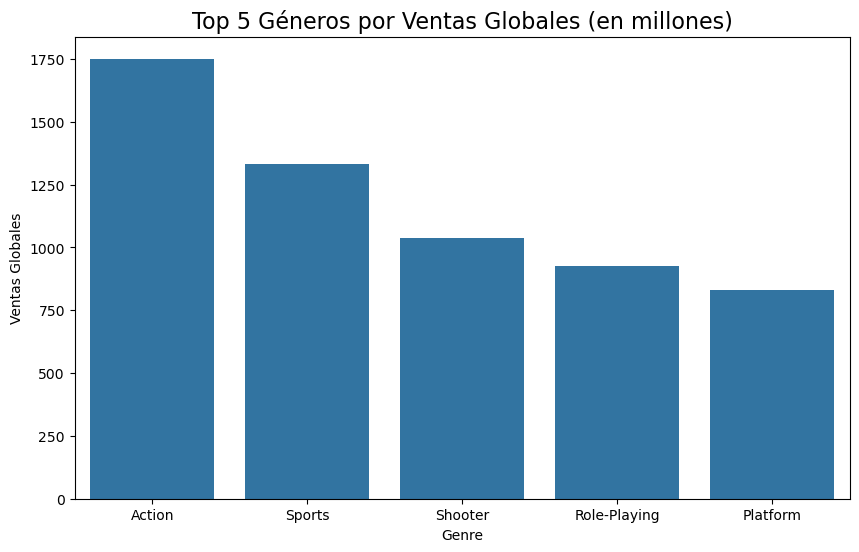


--- 2. Top 10 Plataformas por Ventas Globales ---
Platform
PS2     1255.64
X360     979.96
PS3      957.84
Wii      926.71
DS       822.49
PS       730.66
GBA      318.50
PSP      296.28
PS4      278.10
PC       258.82
Name: Global_Sales, dtype: float64


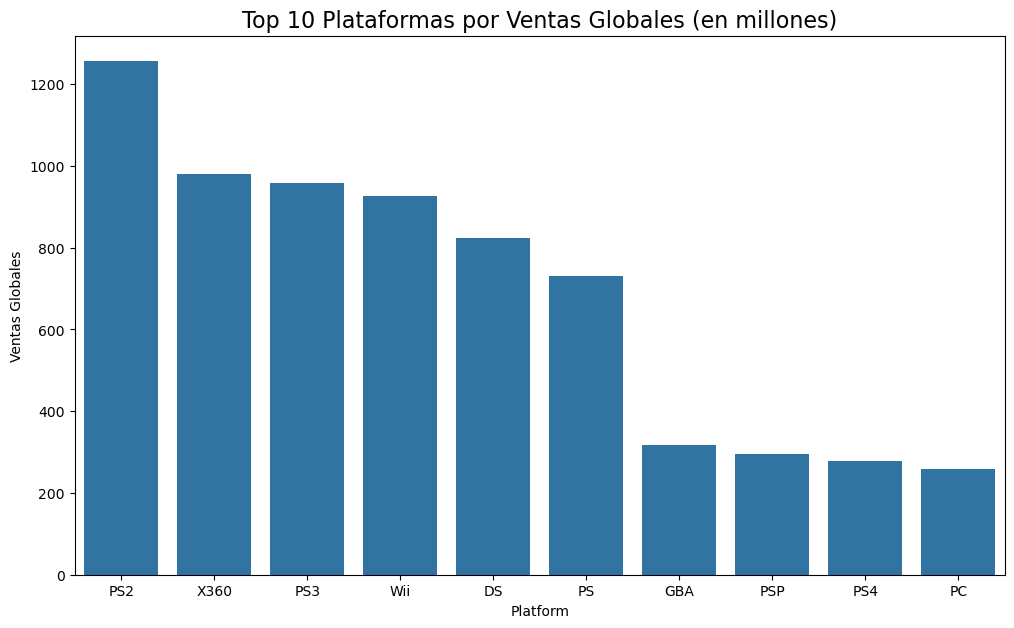


--- 3. Género Más Vendido por Región ---
Género más vendido en Norteamérica: Action
Género más vendido en Europa: Action
Observación: El género 'Action' domina en ambas regiones.

--- 4. Top 5 Editoras (Publishers) por Ventas Globales ---
Publisher
Nintendo                       1786.56
Electronic Arts                1110.32
Activision                      727.46
Sony Computer Entertainment     607.50
Ubisoft                         474.72
Name: Global_Sales, dtype: float64


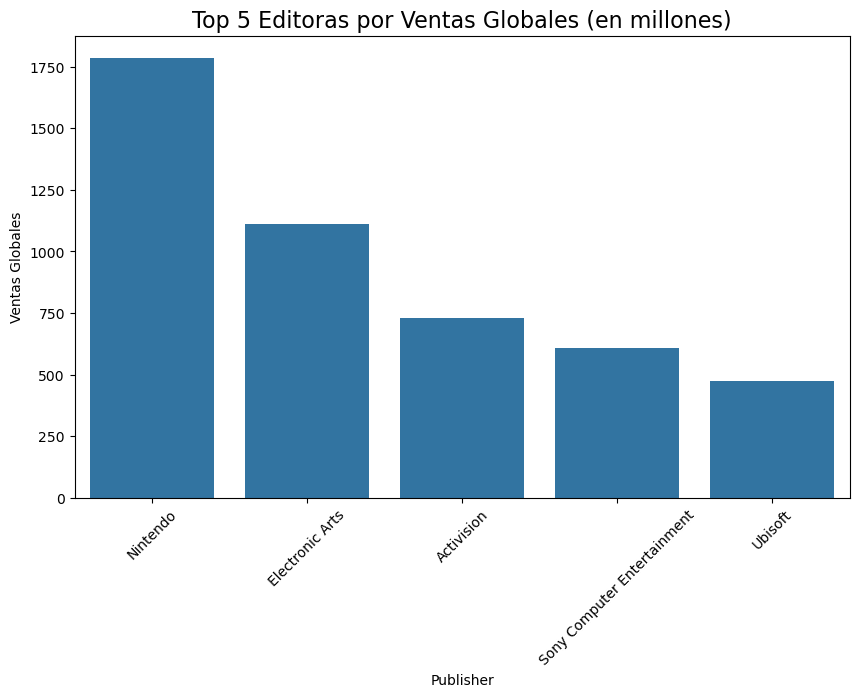

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar los datos
df = pd.read_csv('vgsales.csv')

# --- Pregunta 1: Ranking de Géneros ---
print("--- 1. Top 5 Géneros Más Vendidos Globalmente ---")
top_generos = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False).head(5)
print(top_generos)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_generos.index, y=top_generos.values)
plt.title('Top 5 Géneros por Ventas Globales (en millones)', fontsize=16)
plt.ylabel('Ventas Globales')
plt.show()


# --- Pregunta 2: Dominio de Plataformas ---
print("\n--- 2. Top 10 Plataformas por Ventas Globales ---")
top_plataformas = df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(10)
print(top_plataformas)
plt.figure(figsize=(12, 7))
sns.barplot(x=top_plataformas.index, y=top_plataformas.values)
plt.title('Top 10 Plataformas por Ventas Globales (en millones)', fontsize=16)
plt.ylabel('Ventas Globales')
plt.show()


# --- Pregunta 3: Ventas por Región ---
print("\n--- 3. Género Más Vendido por Región ---")
genero_top_na = df.groupby('Genre')['NA_Sales'].sum().idxmax()
genero_top_eu = df.groupby('Genre')['EU_Sales'].sum().idxmax()
print(f"Género más vendido en Norteamérica: {genero_top_na}")
print(f"Género más vendido en Europa: {genero_top_eu}")
print("Observación: El género 'Action' domina en ambas regiones.")


# --- Pregunta 4: Las Grandes Editoras ---
print("\n--- 4. Top 5 Editoras (Publishers) por Ventas Globales ---")
top_editoras = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(5)
print(top_editoras)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_editoras.index, y=top_editoras.values)
plt.title('Top 5 Editoras por Ventas Globales (en millones)', fontsize=16)
plt.ylabel('Ventas Globales')
plt.xticks(rotation=45)
plt.show()

# Proyecto Mini #1: Análisis de Avistamientos de OVNIs

**Contexto:** Una organización de investigación de fenómenos paranormales te ha contratado para analizar su base de datos histórica de avistamientos de OVNIs en EE. UU. Quieren encontrar patrones temporales y geográficos en los reportes.

**Objetivo:** Explorar un dataset de avistamientos de OVNIs para identificar tendencias a lo largo del tiempo y en diferentes lugares.

**Preguntas a Responder:**
1.  **Limpieza de Datos Temporales:** La columna de fechas está en formato de texto. Conviértela a un formato de fecha (`datetime`) y crea dos nuevas columnas: `Year` y `Month`.
2.  **Tendencia Anual:** ¿En qué año se produjo el mayor número de avistamientos? Crea un gráfico de líneas que muestre el número de avistamientos por año.
3.  **Patrón Estacional:** ¿Qué mes del año es el más común para los avistamientos de OVNIs?
4.  **Geografía de los Avistamientos:** ¿Cuáles son los 10 estados de EE. UU. con más avistamientos reportados?

**Fuente de Datos:** [UFO Sightings en Kaggle](https://www.kaggle.com/datasets/NUFORC/ufo-sightings) (fichero `scrubbed.csv`).

--- 1. Limpiando y Transformando Fechas ---
Columnas 'Year' y 'Month' creadas con éxito.
    datetime  Year  Month
0 1949-10-10  1949     10
1 1949-10-10  1949     10
2 1955-10-10  1955     10
3 1956-10-10  1956     10
4 1960-10-10  1960     10

--- 2. Gráfico: Avistamientos por Año ---


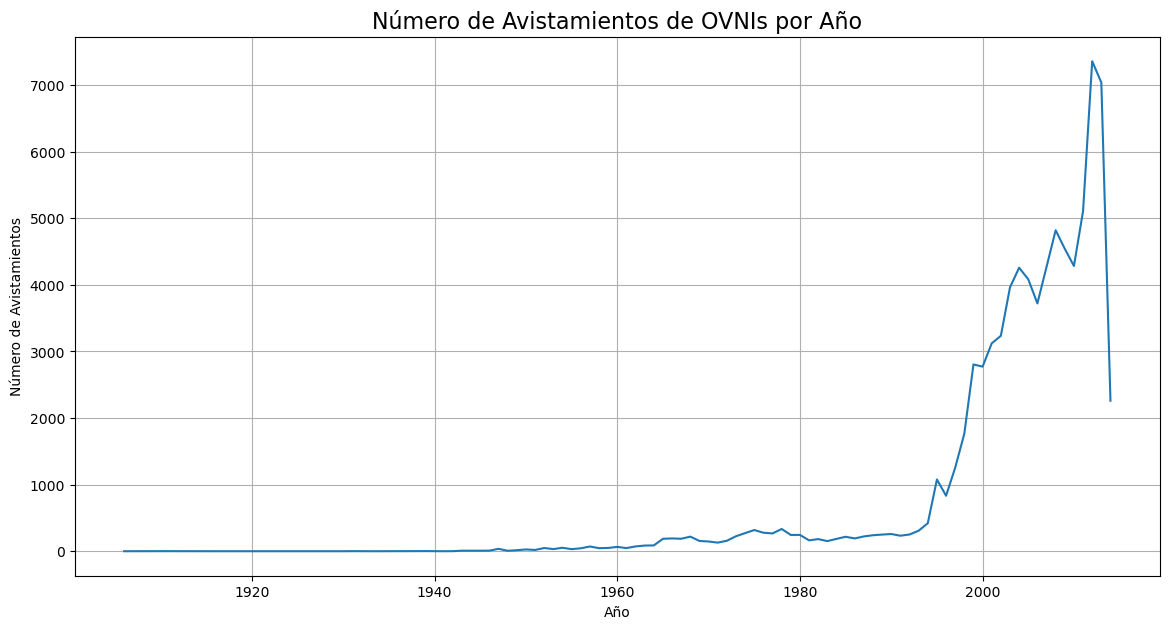

El año con más avistamientos fue: 2012

--- 3. Mes más común para avistamientos ---
El mes más común para avistamientos es el mes número: 7 (Julio)


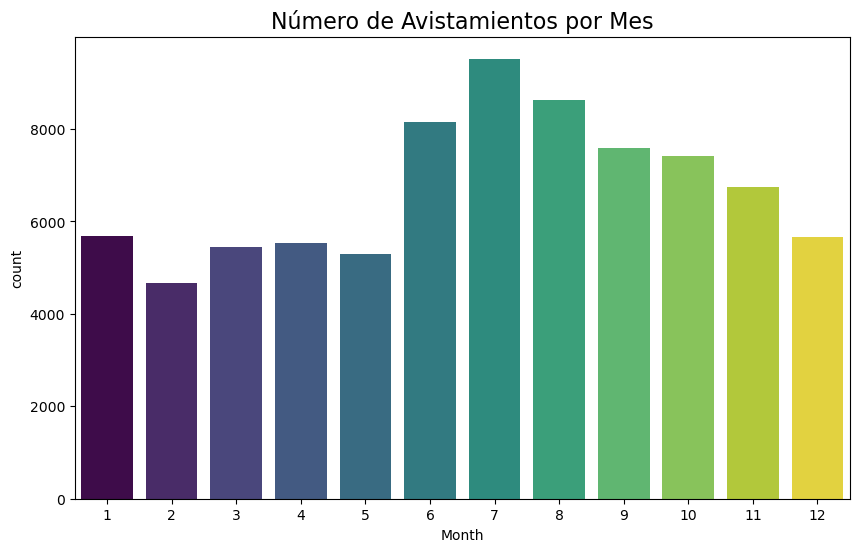


--- 4. Top 10 Estados con más Avistamientos ---
state
CA    9655
WA    4268
FL    4200
TX    3677
NY    3219
AZ    2689
IL    2645
PA    2582
OH    2425
MI    2071
Name: count, dtype: int64


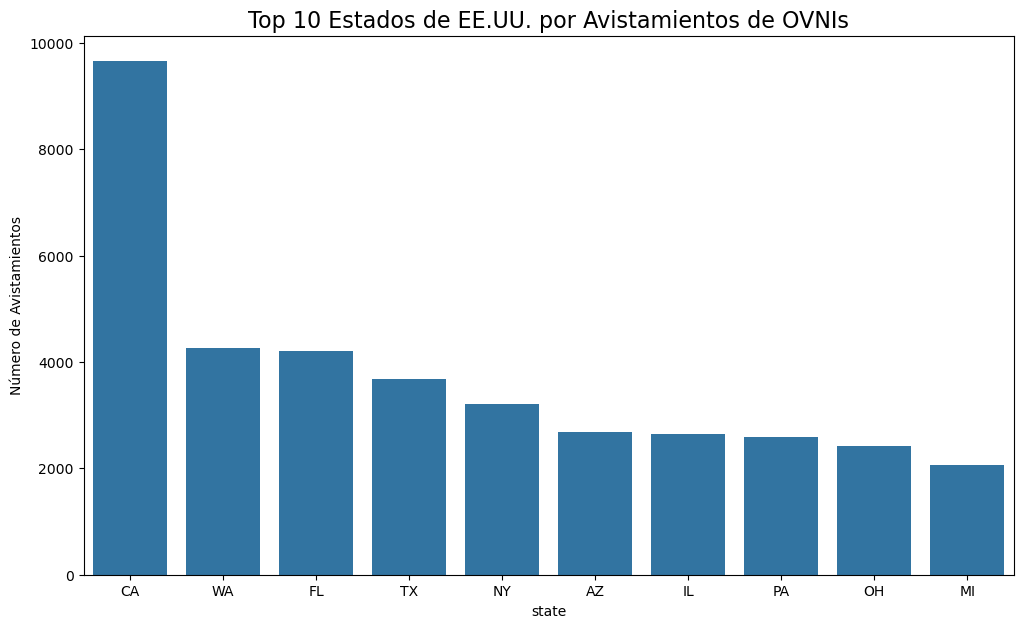

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar los datos
# Advertencia: este dataset es grande, puede tardar un poco
df = pd.read_csv('scrubbed.csv', low_memory=False)

# --- Pregunta 1: Limpieza de Datos Temporales ---
print("--- 1. Limpiando y Transformando Fechas ---")
# La columna 'datetime' tiene un problema: incluye la hora pero a veces no.
# Primero, extraemos la fecha y la hora, separadas por un espacio.
# Nos quedamos solo con la parte de la fecha para simplificar.
df['datetime'] = df['datetime'].str.split(' ').str[0]

# Convertimos a formato datetime. 'coerce' convierte los errores en NaT (Not a Time)
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

# Eliminamos las filas donde la fecha no se pudo convertir
df.dropna(subset=['datetime'], inplace=True)

# Creamos las nuevas columnas
df['Year'] = df['datetime'].dt.year
df['Month'] = df['datetime'].dt.month
print("Columnas 'Year' y 'Month' creadas con éxito.")
print(df[['datetime', 'Year', 'Month']].head())


# --- Pregunta 2: Tendencia Anual ---
print("\n--- 2. Gráfico: Avistamientos por Año ---")
avistamientos_anuales = df['Year'].value_counts().sort_index()

plt.figure(figsize=(14, 7))
avistamientos_anuales.plot(kind='line')
plt.title('Número de Avistamientos de OVNIs por Año', fontsize=16)
plt.xlabel('Año')
plt.ylabel('Número de Avistamientos')
plt.grid(True)
plt.show()
print(f"El año con más avistamientos fue: {avistamientos_anuales.idxmax()}")


# --- Pregunta 3: Patrón Estacional ---
print("\n--- 3. Mes más común para avistamientos ---")
mes_top = df['Month'].value_counts().idxmax()
print(f"El mes más común para avistamientos es el mes número: {mes_top} (Julio)")
plt.figure(figsize=(10, 6))
# Añadimos hue='Month' para ligar el color al dato y legend=False para ocultar la leyenda redundante
sns.countplot(data=df, x='Month', hue='Month', palette='viridis', legend=False)
plt.title('Número de Avistamientos por Mes', fontsize=16)
plt.show()


# --- Pregunta 4: Geografía de los Avistamientos ---
print("\n--- 4. Top 10 Estados con más Avistamientos ---")
# Limpiamos los datos de estado (la columna se llama 'state')
df.dropna(subset=['state'], inplace=True)
df['state'] = df['state'].str.upper() # Estandarizamos a mayúsculas
top_estados = df['state'].value_counts().head(10)
print(top_estados)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_estados.index, y=top_estados.values)
plt.title('Top 10 Estados de EE.UU. por Avistamientos de OVNIs', fontsize=16)
plt.ylabel('Número de Avistamientos')
plt.show()